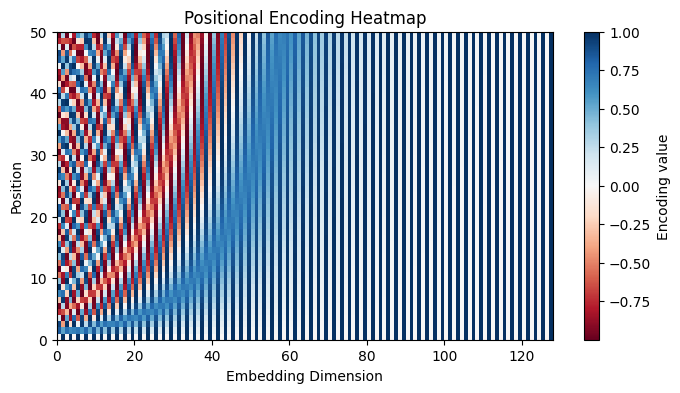

In [4]:
%matplotlib inline
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        position = torch.arange(max_len).unsqueeze(1)  # (max_len,1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe = torch.zeros(max_len, 1, d_model)         # (max_len,1,d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

# 인스턴스 생성
encoding = PositionalEncoding(d_model=128, max_len=50)

# 그래디언트 분리 → CPU 이동 → squeeze → 파이썬 리스트 변환
arr = encoding.pe.detach().cpu().squeeze(1).tolist()  # shape: [50][128] 리스트

# 그리기
plt.figure(figsize=(8, 4))
plt.pcolormesh(arr, cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar(label="Encoding value")
plt.title("Positional Encoding Heatmap")
plt.show()


In [5]:
!python -m spacy download de
!python -m spacy download en

⚠ As of spaCy v3.0, shortcuts like 'de' are deprecated. Please use the
full pipeline package name 'de_core_news_sm' instead.
  Using cached https://github.com/explosion/spacy-models/releases/download/de_core_news_sm-3.8.0/de_core_news_sm-3.8.0-py3-none-any.whl (14.6 MB)
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [18]:
import requests
import gzip
import io
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

# 1) 올바른 raw URL
URL_DE = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.de.gz"
URL_EN = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.en.gz"

def download_and_read_gz(url):
    resp = requests.get(url)
    resp.raise_for_status()
    # 메모리 상에서 gzip 해제
    with gzip.GzipFile(fileobj=io.BytesIO(resp.content)) as gz:
        return [line.decode("utf-8").strip() for line in gz]

# 2) 독일어·영어 문장 리스트 로드
de_sentences = download_and_read_gz(URL_DE)
en_sentences = download_and_read_gz(URL_EN)
raw_train = list(zip(de_sentences, en_sentences))  # [(de, en), ...]

# 3) 토크나이저·특수토큰 세팅
SRC, TGT = "de", "en"
UNK_IDX = 0
specials = ["<unk>", "<pad>", "<bos>", "<eos>"]
tokenizer = {
    SRC: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT: get_tokenizer("spacy", language="en_core_web_sm"),
}

# 4) 토큰 제너레이터
def generate_tokens(data, lang):
    idx = 0 if lang == SRC else 1
    for src, tgt in data:
        text = src if lang == SRC else tgt
        yield tokenizer[lang](text)

# 5) vocab 빌드
vocab = {}
for lang in [SRC, TGT]:
    v = build_vocab_from_iterator(
        generate_tokens(raw_train, lang),
        min_freq=1,
        specials=specials,
        special_first=True,
    )
    v.set_default_index(UNK_IDX)
    vocab[lang] = v

# 확인
print("German vocab size:", len(vocab["de"]))
print("English vocab size:", len(vocab["en"]))


German vocab size: 19214
English vocab size: 10837


In [19]:
import math
import torch
from torch import nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward,
        dropout=0.1,
    ):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )

In [23]:
# --- 앞에서 build한 vocab 딕셔너리 ---
# vocab = {"de": de_vocab, "en": en_vocab}

SRC_LANGUAGE, TGT_LANGUAGE = "de", "en"
PAD_IDX = 1  # 앞서 설정하신 패딩 인덱스

# 모델 생성 시 vocab 대신 vocab_transform 이름으로 참조하거나
# 바로 vocab을 사용하세요.
model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab[SRC_LANGUAGE]),   # ← 여기만 바뀜
    tgt_vocab_size=len(vocab[TGT_LANGUAGE]),   # ← 그리고 여기
    dim_feedforward=512,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)


src_tok_emb
└ embedding
tgt_tok_emb
└ embedding
positional_encoding
└ dropout
transformer
└ encoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
└ decoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
generator


In [25]:
import requests
import gzip
import io
import math
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

# === 0) 앞에서 정의한 download_and_read_gz 함수 재사용 ===
def download_and_read_gz(url):
    resp = requests.get(url)
    resp.raise_for_status()
    with gzip.GzipFile(fileobj=io.BytesIO(resp.content)) as gz:
        return [line.decode("utf-8").strip() for line in gz]

# === 1) train/valid 데이터 로드 ===
URLS = {
    "train": {
        "de": "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.de.gz",
        "en": "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.en.gz",
    },
    "valid": {
        "de": "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.de.gz",
        "en": "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.en.gz",
    }
}

raw_data = {}
for split in ["train", "valid"]:
    de = download_and_read_gz(URLS[split]["de"])
    en = download_and_read_gz(URLS[split]["en"])
    raw_data[split] = list(zip(de, en))

raw_train = raw_data["train"]
raw_valid = raw_data["valid"]

# === 2) 토크나이저 및 vocab 생성 ===
SRC, TGT = "de", "en"
BOS_IDX, EOS_IDX, PAD_IDX, UNK_IDX = 2, 3, 1, 0
specials = ["<unk>", "<pad>", "<bos>", "<eos>"]

tokenizer = {
    SRC: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT: get_tokenizer("spacy", language="en_core_web_sm"),
}

def generate_tokens(data, lang):
    idx = 0 if lang == SRC else 1
    for src, tgt in data:
        text = src if lang == SRC else tgt
        yield tokenizer[lang](text)

vocab = {}
for lang in [SRC, TGT]:
    v = build_vocab_from_iterator(
        generate_tokens(raw_train, lang),
        min_freq=1,
        specials=specials,
        special_first=True,
    )
    v.set_default_index(UNK_IDX)
    vocab[lang] = v

# === 3) 텍스트 → 토큰ID 변환 트랜스폼 정의 ===
def sequential_transforms(*transforms):
    def fn(txt):
        for transform in transforms:
            txt = transform(txt)
        return txt
    return fn

def input_transform(token_ids):
    return torch.cat([
        torch.tensor([BOS_IDX]),
        torch.tensor(token_ids),
        torch.tensor([EOS_IDX])
    ])

text_transform = {}
for lang in [SRC, TGT]:
    text_transform[lang] = sequential_transforms(
        tokenizer[lang],        # raw string → 리스트[str]
        vocab[lang],            # 리스트[str] → 리스트[int]
        input_transform         # 리스트[int] → Tensor[...]
    )

# === 4) collate_fn & DataLoader 생성 ===
def collator(batch):
    src_batch, tgt_batch = [], []
    for src_str, tgt_str in batch:
        src_batch.append(text_transform[SRC](src_str))
        tgt_batch.append(text_transform[TGT](tgt_str))
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

BATCH_SIZE = 128
valid_loader = DataLoader(raw_valid, batch_size=BATCH_SIZE, collate_fn=collator)

# === 5) 한 배치 꺼내서 확인 ===
src_batch, tgt_batch = next(iter(valid_loader))
print("source_batch shape:", src_batch.shape)   # (seq_len, batch)
print("target_batch shape:", tgt_batch.shape)
print("example source indices:\n", src_batch[:, :5])
print("example target indices:\n", tgt_batch[:, :5])


source_batch shape: torch.Size([35, 128])
target_batch shape: torch.Size([30, 128])
example source indices:
 tensor([[   2,    2,    2,    2,    2],
        [  14,    5,    5,   21,    5],
        [  38,   12,   35,   31,   12],
        [  24,  281,   10,  957,   10],
        [ 243,    7, 1205,   18, 7190],
        [2744,    6,   32,  420, 2328],
        [8680,   83,   11,    0,    8],
        [  11,  245,   34,   11,   16],
        [  20,   11,  792,    6,   18],
        [ 892,    6,   13,    0,  362],
        [   3,  444,   17,  318, 3914],
        [   1,    4,    4,   11,   62],
        [   1,    3,    3,    3,    8],
        [   1,    1,    1,    1,   32],
        [   1,    1,    1,    1,    7],
        [   1,    1,    1,    1,    6],
        [   1,    1,    1,    1,  115],
        [   1,    1,    1,    1,  197],
        [   1,    1,    1,    1,    4],
        [   1,    1,    1,    1,    3],
        [   1,    1,    1,    1,    1],
        [   1,    1,    1,    1,    1],
        [  

In [26]:
import torch

# 이미 정의된 DEVICE, PAD_IDX 사용
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# PAD_IDX = 1

def generate_square_subsequent_mask(sz):
    mask = torch.triu(torch.ones((sz, sz), device=DEVICE)) == 1
    mask = (
        mask.float()
        .masked_fill(~mask, float("-inf"))
        .masked_fill(mask, float(0.0))
    )
    return mask

def create_mask(src, tgt_input):
    src_seq_len, _ = src.shape
    tgt_seq_len, _ = tgt_input.shape

    # no future look-ahead for decoder
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    # encoder doesn't need causal mask
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE)

    # padding masks: shape (batch, seq_len)
    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt_input == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# 예시: valid_loader 에서 배치 꺼내기
src_batch, tgt_batch = next(iter(valid_loader))  # src_batch: (S, B), tgt_batch: (T, B)

# decoder input은 <bos> 부터 마지막 전까지
tgt_input = tgt_batch[:-1, :]
# 예측 대상(teacher forcing)은 두 번째 토큰부터 끝까지
tgt_out   = tgt_batch[1:, :]

src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_mask(src_batch, tgt_input)

print("src_mask:",  src_mask.shape)
print(src_mask)

print("tgt_mask:",  tgt_mask.shape)
print(tgt_mask)

print("src_pad_mask:",  src_pad_mask.shape)
print(src_pad_mask)

print("tgt_pad_mask:",  tgt_pad_mask.shape)
print(tgt_pad_mask)


src_mask: torch.Size([35, 35])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tgt_mask: torch.Size([29, 29])
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0.],
        [-inf, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0.],
        [-inf, -inf, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0.],
        [-inf, -inf, -inf, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.

In [2]:
from transformers import GPT2LMHeadModel


model = GPT2LMHeadModel.from_pretrained(pretrained_model_name_or_path="gpt2")

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer
└ wte
└ wpe
└ drop
└ h
│  └ 0
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 1
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 2
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 3
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 4
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 5
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 6
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 7
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 8
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 9
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 10
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 11
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
└ ln_f
lm_head


In [6]:
from transformers import pipeline

generator = pipeline(
    task="text-generation",
    model="gpt2",
    framework="pt",                # ← 여기 추가
)
outputs = generator(
    "Machine learning is",
    max_length=20,
    num_return_sequences=3,
    pad_token_id=generator.tokenizer.eos_token_id
)
print(outputs)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Machine learning is a new field that has gained traction as a field of study that focuses on the neural correlates of knowledge, so that we can better understand it.\n\nAs we have seen, most people are familiar with the concept of "superintelligence". In fact, they have been using it for a long time. It\'s been used successfully to improve our understanding of our own behavior and to generate hypotheses about how we can better understand and improve our lives.\n\nWe have yet to find a single example of a superintelligence that we have not already seen: the human brain. When we think of a superintelligence, it is usually a very simple idea that we have not yet seen. In the last decade, we have learned that this idea holds in many ways, including that it is very fast. And when we talk about the human brain we don\'t just mean "the brain". We also mean the brain where we experience the world. If you think about the brain of a person, you might say that there is a lot 

In [1]:
import torch
from torchtext.datasets import CoLA
from transformers import AutoTokenizer
from torch.utils.data import DataLoader


def collator(batch, tokenizer, device):
    source, labels, texts = zip(*batch)
    tokenized = tokenizer(
        texts,
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(labels, dtype=torch.long).to(device)
    return input_ids, attention_mask, labels


train_data = list(CoLA(split="train"))
valid_data = list(CoLA(split="dev"))
test_data = list(CoLA(split="test"))

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

epochs = 3
batch_size = 16
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device),
    shuffle=True,
)
valid_dataloader = DataLoader(
    valid_data, batch_size=batch_size, collate_fn=lambda x: collator(x, tokenizer, device)
)
test_dataloader = DataLoader(
    test_data, batch_size=batch_size, collate_fn=lambda x: collator(x, tokenizer, device)
)

print("Train Dataset Length :", len(train_data))
print("Valid Dataset Length :", len(valid_data))
print("Test Dataset Length :", len(test_data))

/opt/anaconda3/envs/mxnet39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1


Train Dataset Length : 8550
Valid Dataset Length : 526
Test Dataset Length : 515


In [2]:
import torch
from torch import optim
from transformers import GPT2ForSequenceClassification

# 1) device 정의
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) 모델 로드 및 디바이스 이동
model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2
).to(device)

# 3) 패딩 토큰 설정
model.config.pad_token_id = model.config.eos_token_id

# 4) 옵티마이저 준비
optimizer = optim.Adam(model.parameters(), lr=5e-5)


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        val_loss, val_accuracy = 0.0, 0.0
        
        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits
            loss = outputs.loss

            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            accuracy = calc_accuracy(logits, label_ids)
            
            val_loss += loss.item()
            val_accuracy += accuracy
    
    val_loss = val_loss/len(dataloader)
    val_accuracy = val_accuracy/len(dataloader)
    return val_loss, val_accuracy


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "../models/GPT2ForSequenceClassification.pt")
        print("Saved the model weights")

In [ ]:
model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2
).to(device)
model.config.pad_token_id = model.config.eos_token_id
model.load_state_dict(torch.load("../models/GPT2ForSequenceClassification.pt"))

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")